In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Titanic.csv")

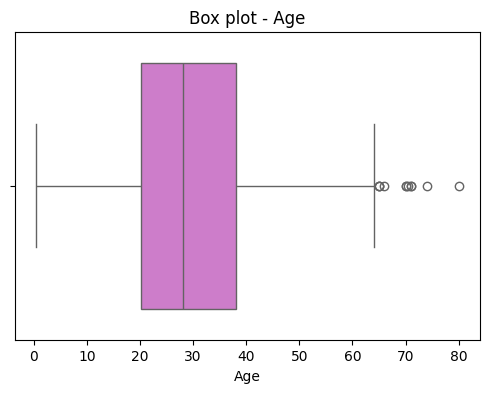

In [3]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'],color='orchid')
plt.title('Box plot - Age')
plt.xlabel('Age')
plt.show()


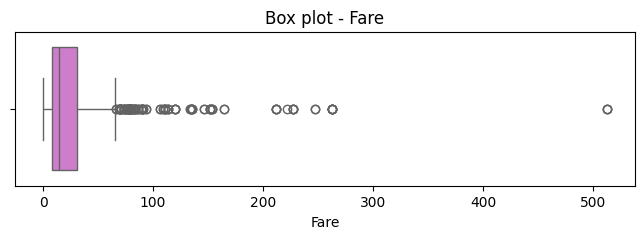

In [4]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['Fare'],color='orchid')
plt.title('Box plot - Fare')
plt.xlabel('Fare')
plt.show()


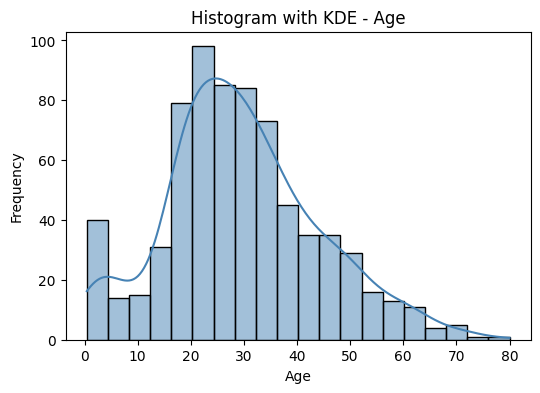

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'],kde=True,color='steelblue')
plt.title('Histogram with KDE - Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

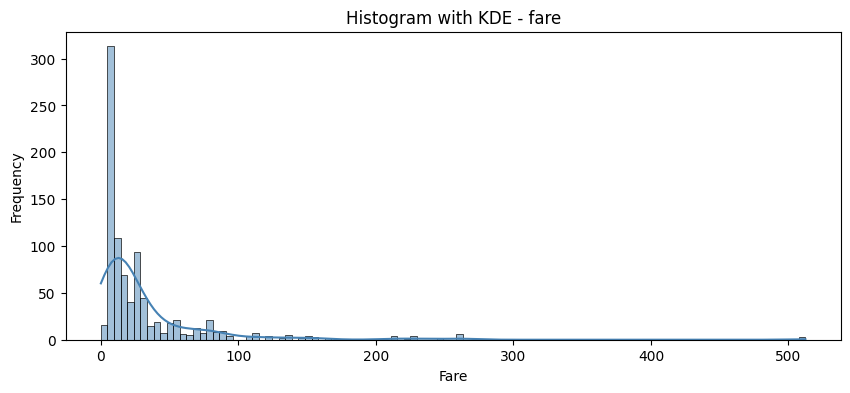

In [6]:
plt.figure(figsize=(10,4))
sns.histplot(df['Fare'],kde=True,color='steelblue')
plt.title('Histogram with KDE - fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

#### How to measure the outliers

In [7]:
IQR=df['Fare'].quantile(0.75)-df['Fare'].quantile(0.25)
IQR

np.float64(23.0896)

In [8]:
#calculating the boundaries
lower_fence=df['Fare'].quantile(0.25)-(IQR*1.5)
upper_fence=df['Fare'].quantile(0.75)+(IQR*1.5)

print("Lower boundary : ",lower_fence)
print("Upper boundary : ",upper_fence)

Lower boundary :  -26.724
Upper boundary :  65.6344


In [9]:
outliers = df[(df['Fare'] > upper_fence) | (df['Fare'] < lower_fence)]
print("Outliers in Fare column:")
print(outliers['Fare'])
print("Number of outliers in Fare column:", len(outliers))

Outliers in Fare column:
1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64
Number of outliers in Fare column: 116


In [10]:
#calculating the boundaries
lower_fence=df['Fare'].quantile(0.25)-(IQR*3)
upper_fence=df['Fare'].quantile(0.75)+(IQR*3)

print("Lower boundary : ",lower_fence)
print("Upper boundary : ",upper_fence)

Lower boundary :  -61.358399999999996
Upper boundary :  100.2688


In [11]:
outliers = df[(df['Fare'] > upper_fence) | (df['Fare'] < lower_fence)]

print("Outliers in Fare column:")
print(outliers['Fare'])
print("Number of outliers in Fare column:", len(outliers))

Outliers in Fare column:
27     263.0000
31     146.5208
88     263.0000
118    247.5208
195    146.5208
215    113.2750
258    512.3292
268    153.4625
269    135.6333
297    151.5500
299    247.5208
305    151.5500
306    110.8833
307    108.9000
311    262.3750
318    164.8667
319    134.5000
325    135.6333
332    153.4625
334    133.6500
337    134.5000
341    263.0000
373    135.6333
377    211.5000
380    227.5250
390    120.0000
393    113.2750
435    120.0000
438    263.0000
498    151.5500
505    108.9000
527    221.7792
537    106.4250
544    106.4250
550    110.8833
557    227.5250
581    110.8833
609    153.4625
659    113.2750
660    133.6500
679    512.3292
689    211.3375
698    110.8833
700    227.5250
708    151.5500
716    227.5250
730    211.3375
737    512.3292
742    262.3750
763    120.0000
779    211.3375
802    120.0000
856    164.8667
Name: Fare, dtype: float64
Number of outliers in Fare column: 53


#### Handling outliers

In [12]:
from scipy.stats import zscore

#drop missing Fare values
df=df[['Fare']].dropna()

#calculate z-scores
df['z_score']=zscore(df['Fare'])

#identify outliers using z-score threshold
df_filtered=df[(df['z_score']>=-3) & (df['z_score']<=3)]

df_filtered

,Fare,z_score
0,7.2500,-0.502445
1,71.2833,0.786845
2,7.9250,-0.488854
3,53.1000,0.420730
4,8.0500,-0.486337
...,...,...
886,13.0000,-0.386671
887,30.0000,-0.044381
888,23.4500,-0.176263
889,30.0000,-0.044381


#### Z-score method

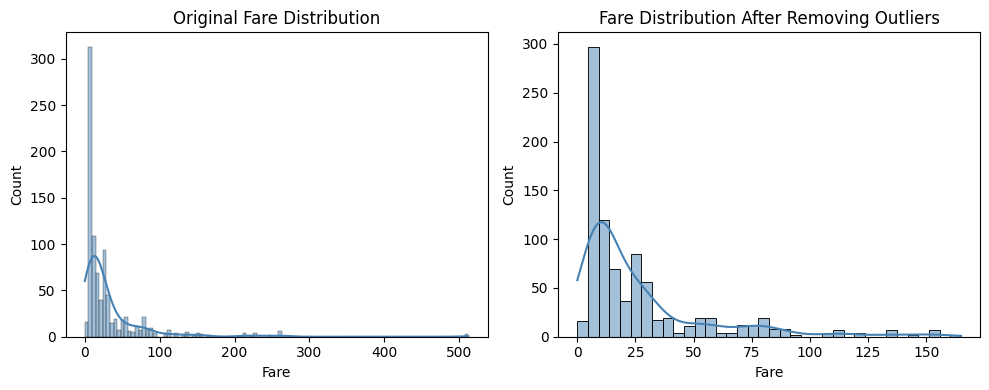

In [13]:
#plotting the z-score outliers
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Fare'],kde=True,color='steelblue')
plt.title('Original Fare Distribution')

#After removing outliers
plt.subplot(1,2,2)
sns.histplot(df_filtered['Fare'],kde=True,color='steelblue')
plt.title('Fare Distribution After Removing Outliers')

plt.tight_layout()
plt.show()

In [14]:
#calculate Q1, Q3 and IQR
Q1=df['Fare'].quantile(0.25)
Q3=df['Fare'].quantile(0.75)
IQR=Q3-Q1
#calculate lower and upper bounds
lower_bound=Q1-(3*IQR)
upper_bound=Q3+(3*IQR)

df_iqr_filtered=df[(df['Fare']>=lower_bound) & (df['Fare']<=upper_bound)]

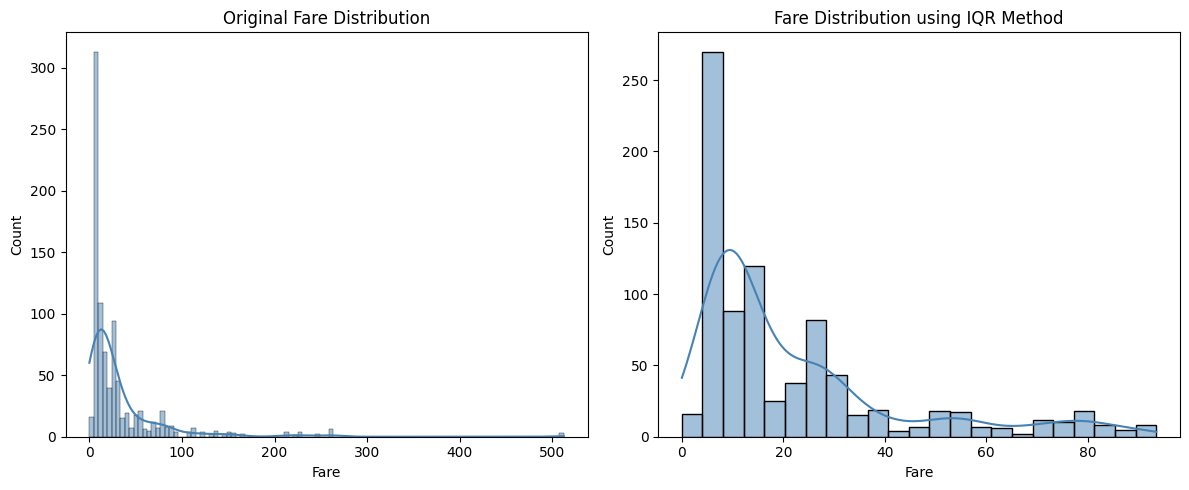

In [15]:
#plotting the z-score outliers
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Fare'],kde=True,color='steelblue')
plt.title('Original Fare Distribution')

#After removing outliers
plt.subplot(1,2,2)
sns.histplot(df_iqr_filtered['Fare'],kde=True,color='steelblue')
plt.title('Fare Distribution using IQR Method')

plt.tight_layout()
plt.show()